In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplcursors
import fastf1
import fastf1.plotting
import colorsys

In [2]:
# Creates the cache directory, if not existent, and enables it
if not os.path.exists('f1_cache'):
    os.makedirs('f1_cache')
fastf1.Cache.enable_cache('f1_cache')

In [3]:
# Let the user select which quali session to analye
print("\n--- Qualify Telemetries ---")
year = int(input("Select year (if using fastf1 select a year after 2018): ").strip())
print(f"\n--- Grand Prix calendar for {year}: ---")
schedule = fastf1.get_event_schedule(year)
gp_events = schedule[schedule['EventFormat'] != 'testing']
for index, row in gp_events.iterrows():
    print(f" Round {row['RoundNumber']}: {row['EventName']} (Suggested location keyword: '{row['Location']}')")
track = input("Select track: ").strip()
session = fastf1.get_session(year, track, 'Q')
session.load()


--- Qualify Telemetries ---

--- Grand Prix calendar for 2025: ---
 Round 1: Australian Grand Prix (Suggested location keyword: 'Melbourne')
 Round 2: Chinese Grand Prix (Suggested location keyword: 'Shanghai')
 Round 3: Japanese Grand Prix (Suggested location keyword: 'Suzuka')
 Round 4: Bahrain Grand Prix (Suggested location keyword: 'Sakhir')
 Round 5: Saudi Arabian Grand Prix (Suggested location keyword: 'Jeddah')
 Round 6: Miami Grand Prix (Suggested location keyword: 'Miami Gardens')
 Round 7: Emilia Romagna Grand Prix (Suggested location keyword: 'Imola')
 Round 8: Monaco Grand Prix (Suggested location keyword: 'Monaco')
 Round 9: Spanish Grand Prix (Suggested location keyword: 'Barcelona')
 Round 10: Canadian Grand Prix (Suggested location keyword: 'Montréal')
 Round 11: Austrian Grand Prix (Suggested location keyword: 'Spielberg')
 Round 12: British Grand Prix (Suggested location keyword: 'Silverstone')
 Round 13: Belgian Grand Prix (Suggested location keyword: 'Spa-Francorch

core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req           

In [4]:
# Let the user select which driver's telemetry to analyze
print(f"\n--- Official drivers found for {track} ({year}) ---")
drivers_list = session.results.sort_values(by='TeamName')
for index, row in drivers_list.iterrows():
    print(f" [{row['Abbreviation']}] {row['FullName']} - Team: {row['TeamName']}")
d1 = input("Insert 1st driver's TAG: ").strip().upper()
d2 = input("Insert 2nd driver's TAG: ").strip().upper()
# Search for the registered lap
try:
    lap_p1 = session.laps.pick_drivers(d1).pick_fastest()
    lap_p2 = session.laps.pick_drivers(d2).pick_fastest()
    # Possible errors output
    if len(lap_p1) == 0 or len(lap_p2) == 0:
        raise ValueError("One or Both the chosen driver's have not partecipated to the session...")
except Exception as e:
    print(f"\n[ERROR] Couldn't find data for the chosen driver: {e}")
    exit()


--- Official drivers found for JED (2025) ---
 [DOO] Jack Doohan - Team: Alpine
 [GAS] Pierre Gasly - Team: Alpine
 [STR] Lance Stroll - Team: Aston Martin
 [ALO] Fernando Alonso - Team: Aston Martin
 [LEC] Charles Leclerc - Team: Ferrari
 [HAM] Lewis Hamilton - Team: Ferrari
 [BEA] Oliver Bearman - Team: Haas F1 Team
 [OCO] Esteban Ocon - Team: Haas F1 Team
 [BOR] Gabriel Bortoleto - Team: Kick Sauber
 [HUL] Nico Hulkenberg - Team: Kick Sauber
 [NOR] Lando Norris - Team: McLaren
 [PIA] Oscar Piastri - Team: McLaren
 [ANT] Kimi Antonelli - Team: Mercedes
 [RUS] George Russell - Team: Mercedes
 [LAW] Liam Lawson - Team: Racing Bulls
 [HAD] Isack Hadjar - Team: Racing Bulls
 [TSU] Yuki Tsunoda - Team: Red Bull Racing
 [VER] Max Verstappen - Team: Red Bull Racing
 [SAI] Carlos Sainz - Team: Williams
 [ALB] Alexander Albon - Team: Williams


In [5]:
# Extract the telemetries
telemetry_p1 = lap_p1.get_car_data().add_distance()
telemetry_p2 = lap_p2.get_car_data().add_distance()
# Assing each driver his color
color_p1 = fastf1.plotting.get_driver_color(d1, session=session)
color_p2 = fastf1.plotting.get_driver_color(d2, session=session)
# Look if they are in the same team, in which case change the color and stye a little
team_p1 = lap_p1['Team']
team_p2 = lap_p2['Team']
if team_p1 == team_p2:
    print(f"\n[INFO] {d1} and {d2} are both in {team_p1}. Generating a distinct color shade...")
    # Convert HEX color to RGB (normalized between 0 and 1)
    hex_color = color_p2.lstrip('#')
    r, g, b = tuple(int(hex_color[i:i+2], 16)/255.0 for i in (0, 2, 4))
    # Convert RGB to HLS (Hue, Lightness, Saturation)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    # Shift lightness: if it's a dark color, make it lighter. If it's light, make it darker.
    if l < 0.5:
        new_l = min(1.0, l + 0.35)
    else:
        new_l = max(0.0, l - 0.35)
    # Convert back to RGB and then to HEX format for Matplotlib
    new_r, new_g, new_b = colorsys.hls_to_rgb(h, new_l, s)
    color_p2 = '#%02x%02x%02x' % (int(new_r*255), int(new_g*255), int(new_b*255))
    # Combine the color shift with a dashed line style for clear distinction
    line_style_p2 = '--'
    alpha_p2 = 0.9

req            INFO 	Using cached data for driver_info



[INFO] NOR and PIA are both in McLaren. Generating a distinct color shade...


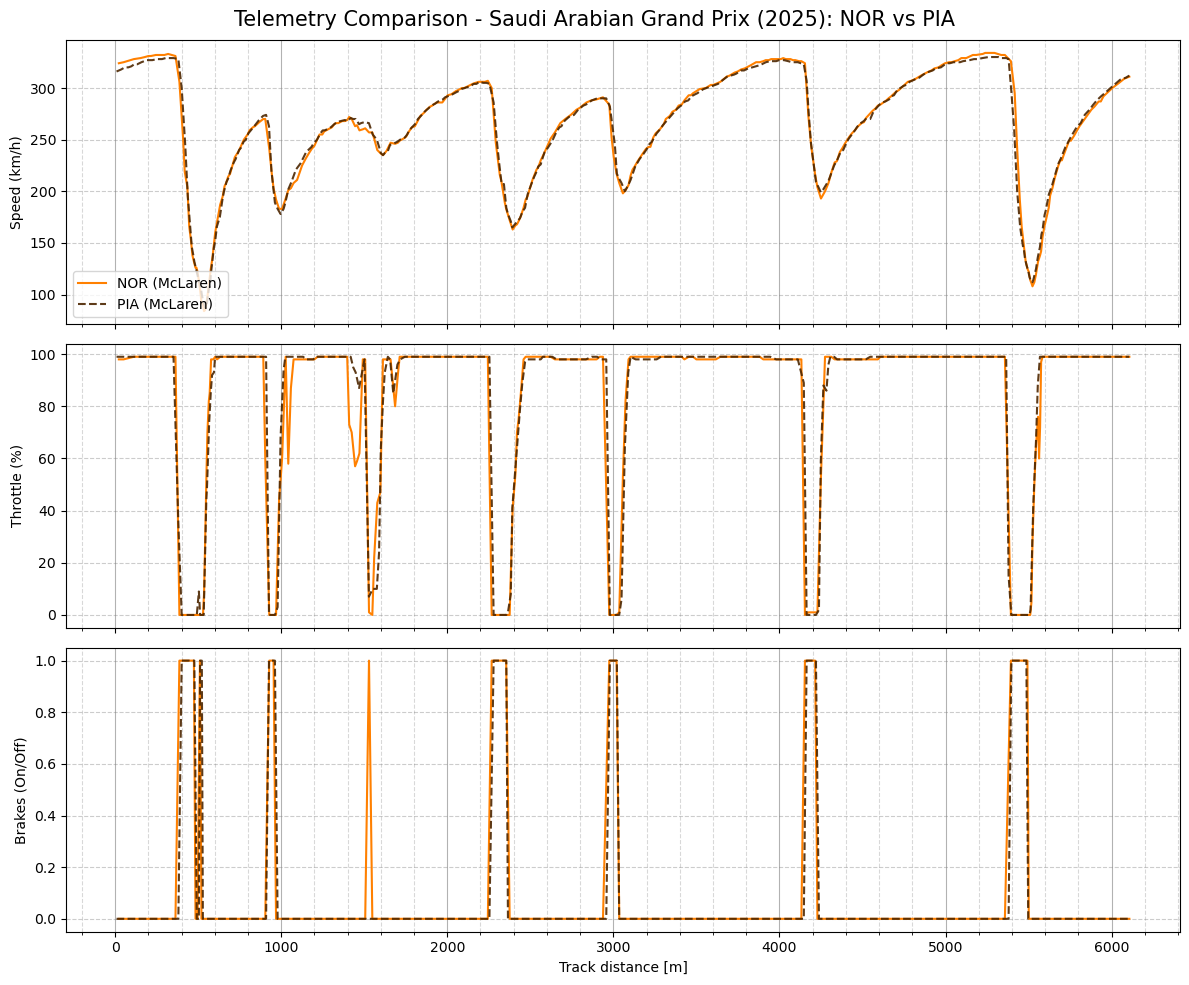

In [6]:
# Prepare the wanted telemetries in SUBPLOTS
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle(f"Telemetry Comparison - {session.event['EventName']} ({year}): {d1} vs {d2}", fontsize=15)
# --- SUBPLOT 1 (Speed) ---
line1_speed, = ax[0].plot(telemetry_p1['Distance'], telemetry_p1['Speed'], label=f"{d1} ({team_p1})", color=color_p1, linewidth=1.5)
line2_speed, = ax[0].plot(telemetry_p2['Distance'], telemetry_p2['Speed'], label=f"{d2} ({team_p2})", color=color_p2, linewidth=1.5, linestyle=line_style_p2, alpha=alpha_p2)
ax[0].set_ylabel('Speed (km/h)')
ax[0].legend(loc='lower left')
# --- SUBPLOT 2 (Throttle) ---
line1_throt, = ax[1].plot(telemetry_p1['Distance'], telemetry_p1['Throttle'], color=color_p1, linewidth=1.5)
line2_throt, = ax[1].plot(telemetry_p2['Distance'], telemetry_p2['Throttle'], color=color_p2, linewidth=1.5, linestyle=line_style_p2, alpha=alpha_p2)
ax[1].set_ylabel('Throttle (%)')
# --- SUBPLOT 3 (Brake) ---
line1_brake, = ax[2].plot(telemetry_p1['Distance'], telemetry_p1['Brake'], color=color_p1, linewidth=1.5)
line2_brake, = ax[2].plot(telemetry_p2['Distance'], telemetry_p2['Brake'], color=color_p2, linewidth=1.5, linestyle=line_style_p2, alpha=alpha_p2)
ax[2].set_ylabel('Brakes (On/Off)')
ax[2].set_xlabel('Track distance [m]')

for axis in ax:
    axis.xaxis.set_major_locator(ticker.MultipleLocator(1000))
    axis.grid(True, which='major', linestyle='-', alpha=0.6, color='gray')
    axis.xaxis.set_minor_locator(ticker.MultipleLocator(200))
    axis.grid(True, which='minor', linestyle='--', alpha=0.3, color='gray')
    axis.yaxis.grid(True, linestyle='--', alpha=0.4)

cursor = mplcursors.cursor([line1_speed, line2_speed, line1_throt, line2_throt, line1_brake, line2_brake], hover=True)
@cursor.connect("add")
def on_add(sel):
    label = sel.artist.get_label()
    if "_" in label: 
        label = d1 if sel.artist.get_color() == color_p1 else d2
    x_dist = sel.target[0]
    y_val = sel.target[1]
    
    if sel.artist in [line1_speed, line2_speed]:
        sel.annotation.set_text(f"{label}\nDist: {x_dist:.0f}m\nSpeed: {y_val:.1f} km/h")
    elif sel.artist in [line1_throt, line2_throt]:
        sel.annotation.set_text(f"{label}\nDist: {x_dist:.0f}m\nGas: {y_val:.0f}%")
    else:
        sel.annotation.set_text(f"{label}\nDist: {x_dist:.0f}m\nBrake: {'ON' if y_val > 0.1 else 'OFF'}")
    
    sel.annotation.get_bbox_patch().set(fc="#222222", alpha=0.8, boxstyle="round,pad=0.5")
    sel.annotation.arrow_patch.set(arrowstyle="->", color="white")

# Plot it Baby
plt.tight_layout()
plt.show()